<a href="https://colab.research.google.com/github/Moogi8178/customer-churn/blob/main/Customer_Churn_DNN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Customer Churn Prediction Using Deep Neural Networks
### Meru University of Science and Technology — BSc Data Science
**Student:** Finley Barongo Magembe | **Reg No:** CT204/109437/22

---
This notebook implements the full pipeline described in the research proposal:
1. Data Loading & Exploration
2. Data Preprocessing
3. Baseline ML Models (Logistic Regression, Decision Tree, KNN)
4. Advanced ML Models (Random Forest, XGBoost, LightGBM)
5. Deep Neural Network (DNN) — **primary model**
6. Model Evaluation & Comparison
7. SHAP Explainability

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install required packages (run once)
!pip install xgboost lightgbm shap imbalanced-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

# Gradient boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Explainability
import shap

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries loaded successfully')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ All libraries loaded successfully
TensorFlow version: 2.19.0
GPU available: True


## 📂 Step 2: Load Dataset

> **Upload** `churn_csv.csv` using the Colab file upload button (📁 icon on the left sidebar), then run the cell below.

In [4]:
from google.colab import files

# Option A: Upload manually
uploaded = files.upload()   # Select churn_csv.csv from your computer
df = pd.read_csv('churn.csv.csv') # Corrected filename

# Option B: If already in Colab filesystem, use:
# df = pd.read_csv('churn_csv.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Saving churn_csv.csv to churn_csv.csv
Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [5]:
print('='*50)
print('DATASET OVERVIEW')
print('='*50)
print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicated rows: {df.duplicated().sum()}')

DATASET OVERVIEW
Shape: (10000, 14)

Column dtypes:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicated rows: 0


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Class Distribution:
  Not Churned (0): 7963  (79.6%)
  Churned     (1): 2037  (20.4%)


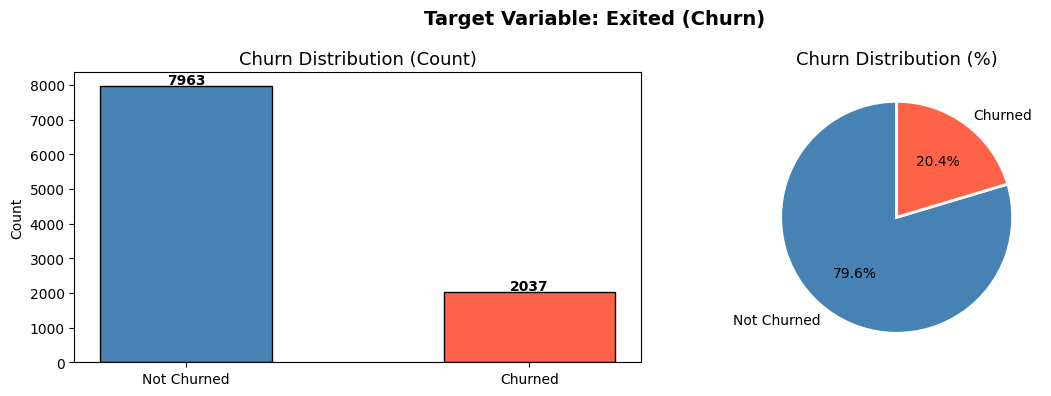

In [7]:
# Target variable distribution
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  Not Churned (0): {churn_counts[0]}  ({churn_pct[0]:.1f}%)')
print(f'  Churned     (1): {churn_counts[1]}  ({churn_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=13)

plt.suptitle('Target Variable: Exited (Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

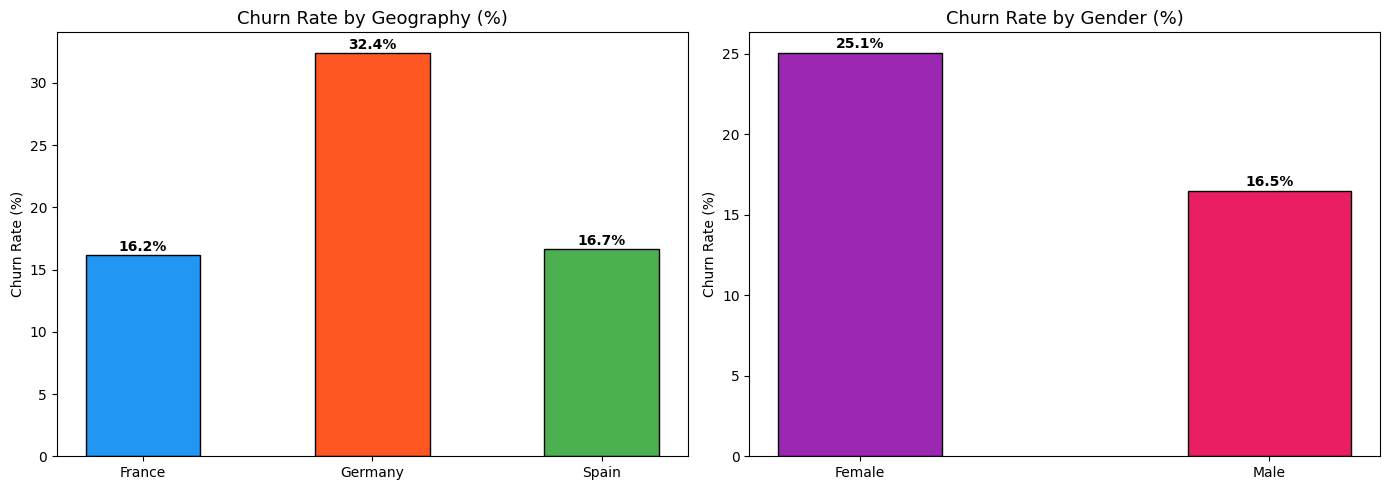

In [8]:
# Churn by Geography and Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
axes[0].bar(geo_churn.index, geo_churn.values, color=['#2196F3','#FF5722','#4CAF50'],
            edgecolor='black', width=0.5)
axes[0].set_title('Churn Rate by Geography (%)', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(geo_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

gender_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[1].bar(gender_churn.index, gender_churn.values, color=['#9C27B0', '#E91E63'],
            edgecolor='black', width=0.4)
axes[1].set_title('Churn Rate by Gender (%)', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

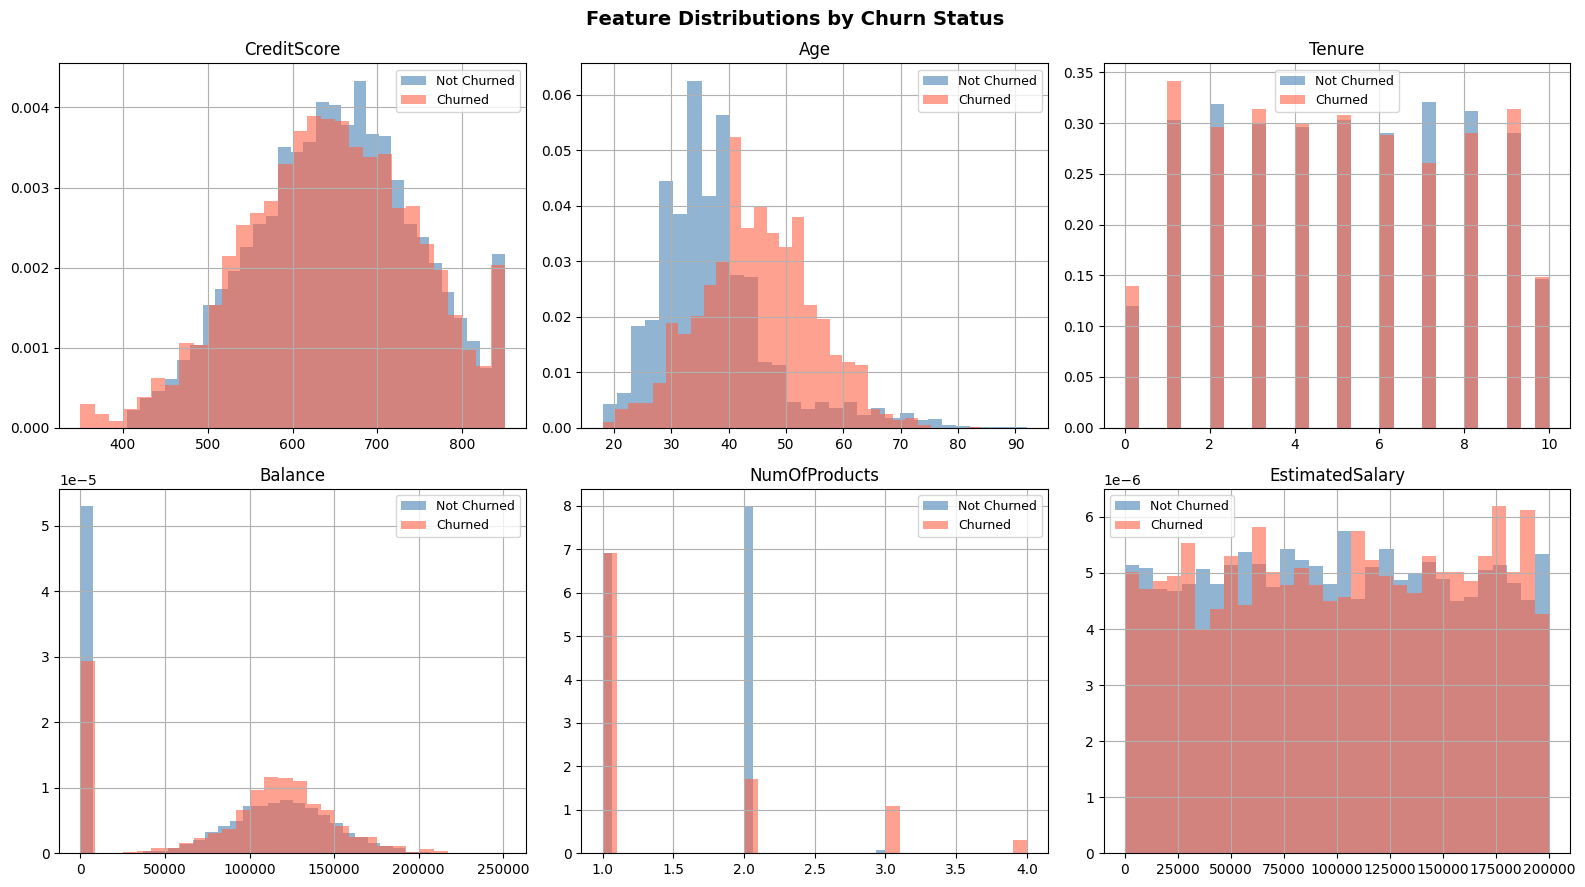

In [9]:
# Numerical feature distributions by churn status
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    df[df['Exited']==0][feat].hist(ax=axes[i], bins=30, alpha=0.6,
                                   color='steelblue', label='Not Churned', density=True)
    df[df['Exited']==1][feat].hist(ax=axes[i], bins=30, alpha=0.6,
                                   color='tomato', label='Churned', density=True)
    axes[i].set_title(feat, fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

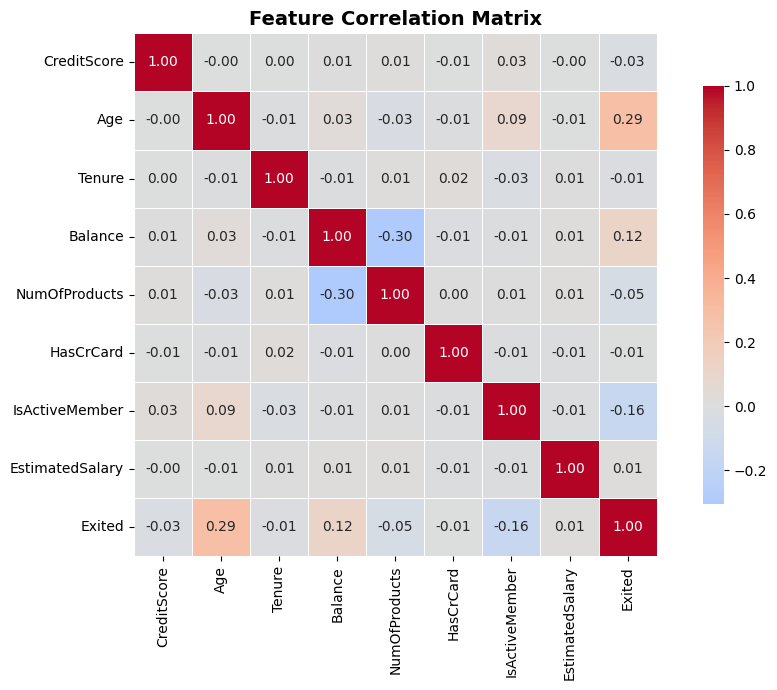

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'HasCrCard', 'IsActiveMember',
             'EstimatedSalary', 'Exited']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 4: Data Preprocessing
Following Section 3.3 of the research proposal.

In [11]:
# Drop irrelevant columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print('Columns after dropping irrelevant features:', df_clean.columns.tolist())

# --- Handle missing values ---
# Numerical: impute with median
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols.remove('Exited')  # Don't impute target
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Categorical: impute with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

Columns after dropping irrelevant features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Missing values after imputation: 0


In [12]:
# --- Encode categorical variables ---
# Gender: Label encoding (binary)
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Female=0, Male=1

# Geography: One-Hot Encoding (multi-category → avoids spurious ordinal)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=False)
# Convert bool columns to int
for col in df_clean.select_dtypes(include='bool').columns:
    df_clean[col] = df_clean[col].astype(int)

print('Columns after encoding:', df_clean.columns.tolist())
df_clean.head(3)

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0


In [13]:
# --- Feature / Target split ---
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature names  : {X.columns.tolist()}')

Features shape : (10000, 12)
Target shape   : (10000,)
Feature names  : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


In [14]:
# --- Train / Validation / Test split  (70 : 15 : 15 as per Section 3.5) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15/0.85,
    random_state=42, stratify=y_train_full
)

print(f'Train set   : {X_train.shape}  | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Val set     : {X_val.shape}   | Churn rate: {y_val.mean()*100:.1f}%')
print(f'Test set    : {X_test.shape}   | Churn rate: {y_test.mean()*100:.1f}%')

Train set   : (7000, 12)  | Churn rate: 20.4%
Val set     : (1500, 12)   | Churn rate: 20.3%
Test set    : (1500, 12)   | Churn rate: 20.4%


In [15]:
# --- Feature scaling (StandardScaler for DNN; also used for LR, KNN) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit ONLY on train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# --- Handle class imbalance with SMOTE on training set only ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f'After SMOTE — Train size: {X_train_res.shape}')
print(f'Class distribution: {pd.Series(y_train_res).value_counts().to_dict()}')

After SMOTE — Train size: (11148, 12)
Class distribution: {0: 5574, 1: 5574}


## 🤖 Step 5: Baseline & ML Models
Implements Section 3.4 baseline and advanced ML models for comparison.

In [16]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
        'AUC-ROC'  : roc_auc_score(y_te, y_proba),
    }
    print(f"\n{'='*45}")
    print(f'  {name}')
    print(f"{'='*45}")
    for k, v in results.items():
        if k != 'Model':
            print(f'  {k:12s}: {v:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["Not Churned","Churned"])}')
    return results, model

In [17]:
all_results = []
trained_models = {}

# --- Baseline Models (scaled data) ---
baselines = [
    ('Logistic Regression', LogisticRegression(max_iter=500, random_state=42)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=6, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7)),
]

for name, model in baselines:
    res, trained = evaluate_model(name, model, X_train_res, y_train_res, X_test_sc, y_test)
    all_results.append(res)
    trained_models[name] = trained


  Logistic Regression
  Accuracy    : 0.7040
  Precision   : 0.3750
  Recall      : 0.6765
  F1-Score    : 0.4825
  AUC-ROC     : 0.7622

              precision    recall  f1-score   support

 Not Churned       0.90      0.71      0.79      1194
     Churned       0.38      0.68      0.48       306

    accuracy                           0.70      1500
   macro avg       0.64      0.69      0.64      1500
weighted avg       0.79      0.70      0.73      1500


  Decision Tree
  Accuracy    : 0.7860
  Precision   : 0.4822
  Recall      : 0.6634
  F1-Score    : 0.5585
  AUC-ROC     : 0.8444

              precision    recall  f1-score   support

 Not Churned       0.90      0.82      0.86      1194
     Churned       0.48      0.66      0.56       306

    accuracy                           0.79      1500
   macro avg       0.69      0.74      0.71      1500
weighted avg       0.82      0.79      0.80      1500


  K-Nearest Neighbors
  Accuracy    : 0.7280
  Precision   : 0.3959
  Rec

In [18]:
# --- Advanced ML Models (raw data works fine for tree-based) ---
X_train_raw_res, y_train_raw_res = smote.fit_resample(X_train, y_train)

advanced = [
    ('Random Forest', RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1)),
    ('XGBoost', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1)),
    ('LightGBM', LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        num_leaves=31, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1)),
]

for name, model in advanced:
    res, trained = evaluate_model(name, model, X_train_raw_res, y_train_raw_res, X_test, y_test)
    all_results.append(res)
    trained_models[name] = trained


  Random Forest
  Accuracy    : 0.8147
  Precision   : 0.5414
  Recall      : 0.5980
  F1-Score    : 0.5683
  AUC-ROC     : 0.8399

              precision    recall  f1-score   support

 Not Churned       0.89      0.87      0.88      1194
     Churned       0.54      0.60      0.57       306

    accuracy                           0.81      1500
   macro avg       0.72      0.73      0.73      1500
weighted avg       0.82      0.81      0.82      1500


  XGBoost
  Accuracy    : 0.8307
  Precision   : 0.5788
  Recall      : 0.6242
  F1-Score    : 0.6006
  AUC-ROC     : 0.8554

              precision    recall  f1-score   support

 Not Churned       0.90      0.88      0.89      1194
     Churned       0.58      0.62      0.60       306

    accuracy                           0.83      1500
   macro avg       0.74      0.75      0.75      1500
weighted avg       0.84      0.83      0.83      1500


  LightGBM
  Accuracy    : 0.8280
  Precision   : 0.5745
  Recall      : 0.6046
  F1-

## 🧠 Step 6: Deep Neural Network (DNN) — Primary Model
Architecture from Section 3.4: dense layers → BatchNorm → Dropout → Sigmoid output.

In [19]:
def build_dnn(input_dim):
    """
    DNN architecture as per the research proposal (Section 3.4):
    - Fully connected dense layers with ReLU
    - Batch Normalization
    - Dropout to prevent overfitting
    - Sigmoid output for binary classification
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden layer 2
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Hidden layer 4
        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output layer — sigmoid for binary classification
        layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

dnn_model = build_dnn(X_train_res.shape[1])
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,513 (189.50 KB)

 Trainable params: 47,553 (185.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
# Callbacks: Early stopping + LR reduction (Section 3.4)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Train the DNN
history = dnn_model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_sc, y_val),
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.6838 - auc: 0.7536 - loss: 0.6226 - precision: 0.6740 - recall: 0.7119 - val_accuracy: 0.7093 - val_auc: 0.8329 - val_loss: 0.5765 - val_precision: 0.3942 - val_recall: 0.8000 - learning_rate: 0.0010
Epoch 2/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7548 - auc: 0.8299 - loss: 0.5418 - precision: 0.7541 - recall: 0.7560 - val_accuracy: 0.7767 - val_auc: 0.8544 - val_loss: 0.5009 - val_precision: 0.4705 - val_recall: 0.7836 - learning_rate: 0.0010
Epoch 3/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7687 - auc: 0.8479 - loss: 0.5182 - precision: 0.7697 - recall: 0.7670 - val_accuracy: 0.7933 - val_auc: 0.8583 - val_loss: 0.4768 - val_precision: 0.4948 - val_recall: 0.7738 - learning_rate: 0.0010
Epoch 4/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7794 - auc: 0.8586 - loss: 0.5014 - precision: 0.7798 - recall: 0.7788 - val_accuracy: 0.7907 - val_auc: 0.8588 - val_loss: 0.4689

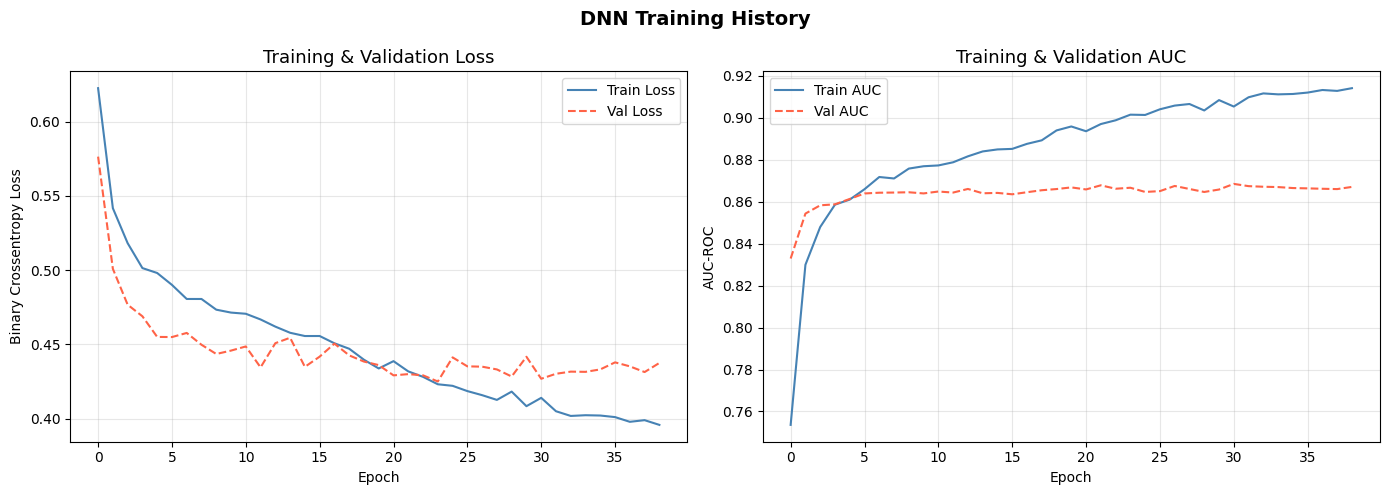

In [21]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC', color='steelblue')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='tomato', linestyle='--')
axes[1].set_title('Training & Validation AUC', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Evaluate DNN on test set
y_proba_dnn = dnn_model.predict(X_test_sc).flatten()
y_pred_dnn  = (y_proba_dnn >= 0.5).astype(int)

dnn_results = {
    'Model'    : 'Deep Neural Network',
    'Accuracy' : accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn),
    'Recall'   : recall_score(y_test, y_pred_dnn),
    'F1-Score' : f1_score(y_test, y_pred_dnn),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_dnn),
}
all_results.append(dnn_results)

print("='"*22)
print('  Deep Neural Network — Test Set Performance')
print("='"*22)
for k, v in dnn_results.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')
print(f'\n{classification_report(y_test, y_pred_dnn, target_names=["Not Churned","Churned"])}')

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
='='='='='='='='='='='='='='='='='='='='='='
  Deep Neural Network — Test Set Performance
='='='='='='='='='='='='='='='='='='='='='='
  Accuracy    : 0.7933
  Precision   : 0.4957
  Recall      : 0.7549
  F1-Score    : 0.5984
  AUC-ROC     : 0.8506

              precision    recall  f1-score   support

 Not Churned       0.93      0.80      0.86      1194
     Churned       0.50      0.75      0.60       306

    accuracy                           0.79      1500
   macro avg       0.71      0.78      0.73      1500
weighted avg       0.84      0.79      0.81      1500



## 📊 Step 7: Model Comparison & Evaluation (Section 3.5)

In [23]:
# Summary table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('AUC-ROC', ascending=False)

# Format nicely
display(results_df.style
        .format('{:.4f}')
        .background_gradient(cmap='YlGn', axis=0)
        .set_caption('📋 Model Performance Comparison (Test Set)'))

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
XGBoost,0.8307,0.5788,0.6242,0.6006,0.8554
LightGBM,0.8280,0.5745,0.6046,0.5892,0.8547
Deep Neural Network,0.7933,0.4957,0.7549,0.5984,0.8506
Decision Tree,0.7860,0.4822,0.6634,0.5585,0.8444
Random Forest,0.8147,0.5414,0.5980,0.5683,0.8399
K-Nearest Neighbors,0.7280,0.3959,0.6340,0.4874,0.7660
Logistic Regression,0.7040,0.3750,0.6765,0.4825,0.7622


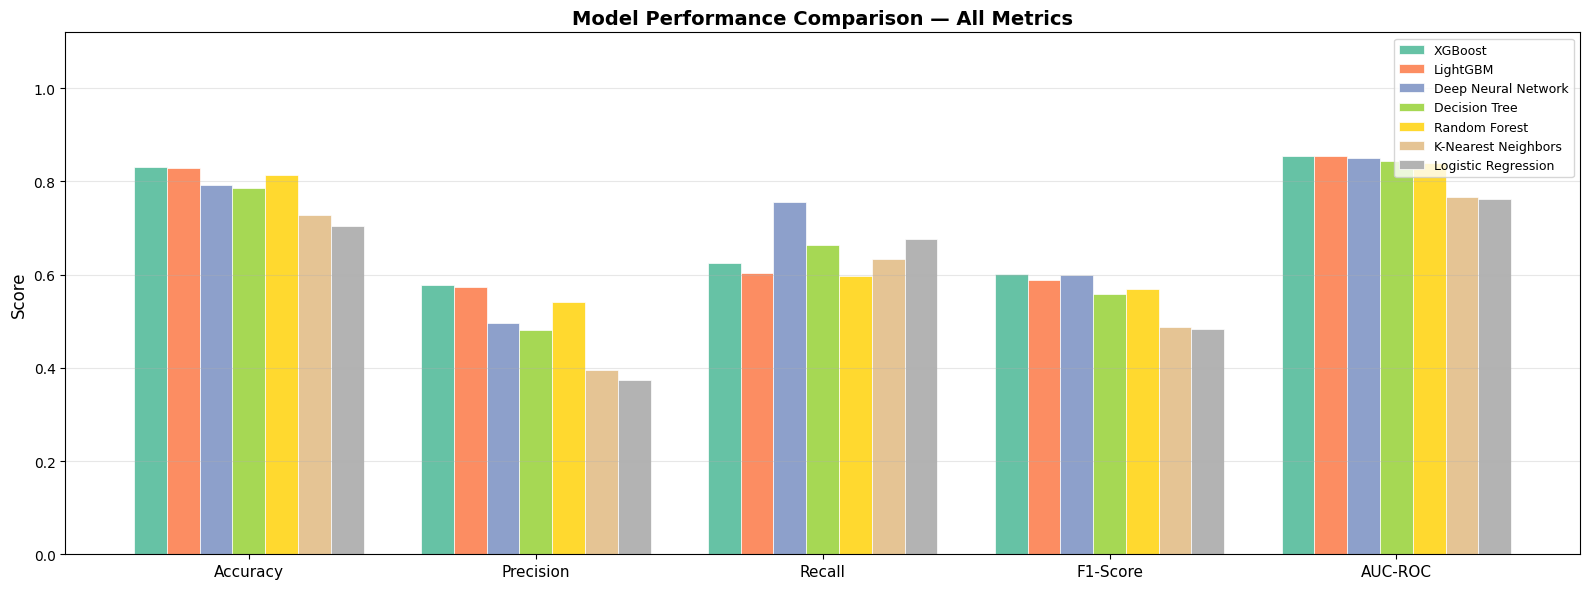

In [24]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
n_models = len(results_df)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(16, 6))
colors = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, row[metrics].values, width,
                  label=model_name, color=colors[i], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

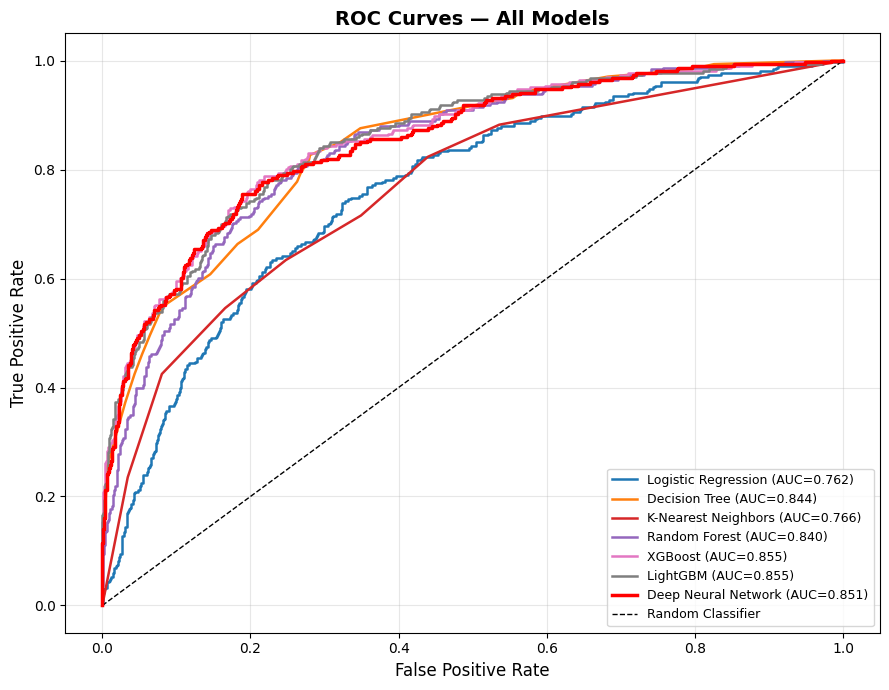

In [25]:
# ROC Curves for all models
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = plt.cm.tab10(np.linspace(0, 0.9, len(all_results)))

# ML models
ml_model_map = {
    'Logistic Regression' : (trained_models['Logistic Regression'], X_test_sc),
    'Decision Tree'       : (trained_models['Decision Tree'],       X_test_sc),
    'K-Nearest Neighbors' : (trained_models['K-Nearest Neighbors'], X_test_sc),
    'Random Forest'       : (trained_models['Random Forest'],       X_test),
    'XGBoost'             : (trained_models['XGBoost'],             X_test),
    'LightGBM'            : (trained_models['LightGBM'],            X_test),
}

for idx, (name, (model, X_t)) in enumerate(ml_model_map.items()):
    proba = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[idx], lw=1.8,
            label=f'{name} (AUC={auc_val:.3f})')

# DNN
fpr_d, tpr_d, _ = roc_curve(y_test, y_proba_dnn)
auc_d = auc(fpr_d, tpr_d)
ax.plot(fpr_d, tpr_d, color='red', lw=2.5, linestyle='-',
        label=f'Deep Neural Network (AUC={auc_d:.3f})', zorder=10)

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

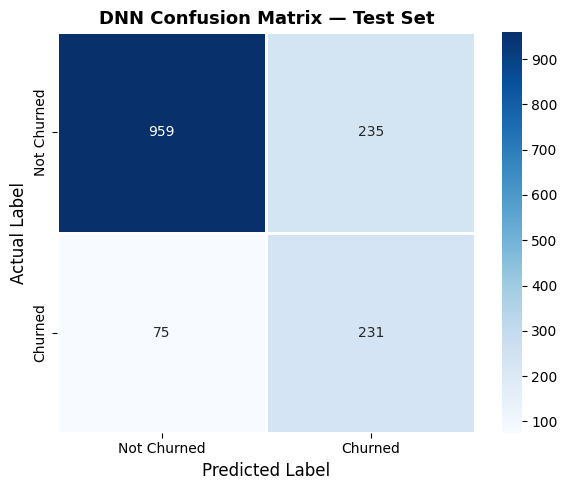

True Negatives  (TN): 959
False Positives (FP): 235
False Negatives (FN): 75
True Positives  (TP): 231


In [26]:
# Confusion Matrix for DNN
cm = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1, linecolor='white')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('DNN Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

## 🔬 Step 8: SHAP Explainability (Specific Objective 4)
Using SHAP values to identify the most important churn predictors.

Computing SHAP values for XGBoost...


 98%|===================| 1474/1500 [00:13<00:00]       

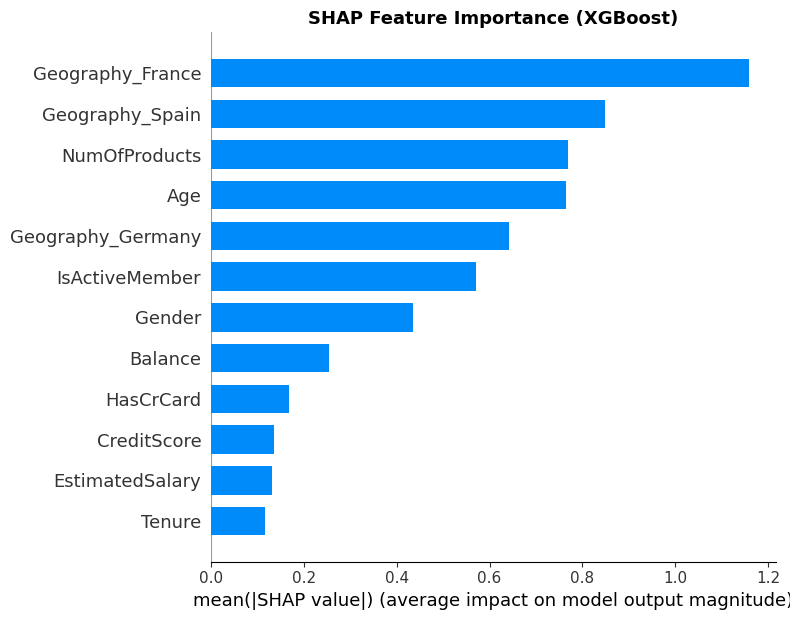

In [27]:
# SHAP on XGBoost (tree-based models have native SHAP support)
print('Computing SHAP values for XGBoost...')
explainer_xgb = shap.Explainer(trained_models['XGBoost'], X_test)
shap_values   = explainer_xgb(X_test)

# Summary plot — feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

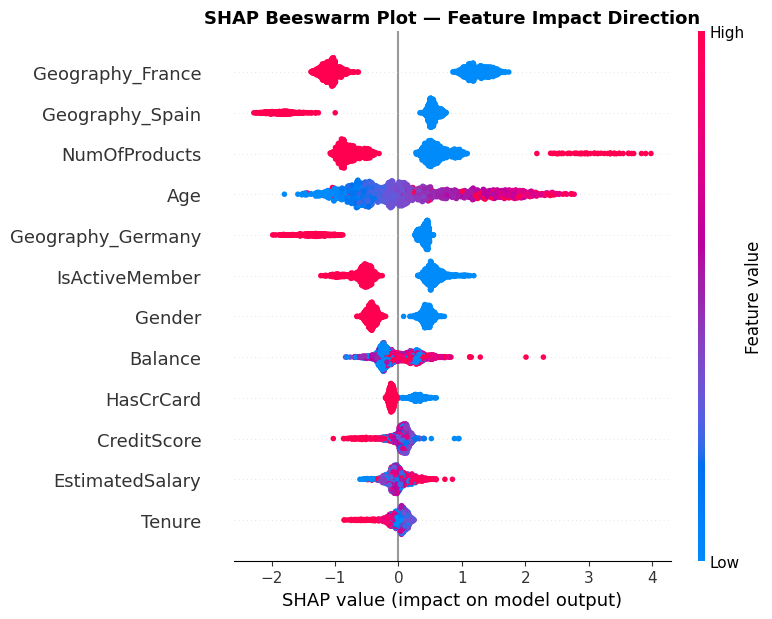

In [28]:
# SHAP Beeswarm (shows direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for test customer #1058
Actual label   : 1
Predicted prob : 0.9945


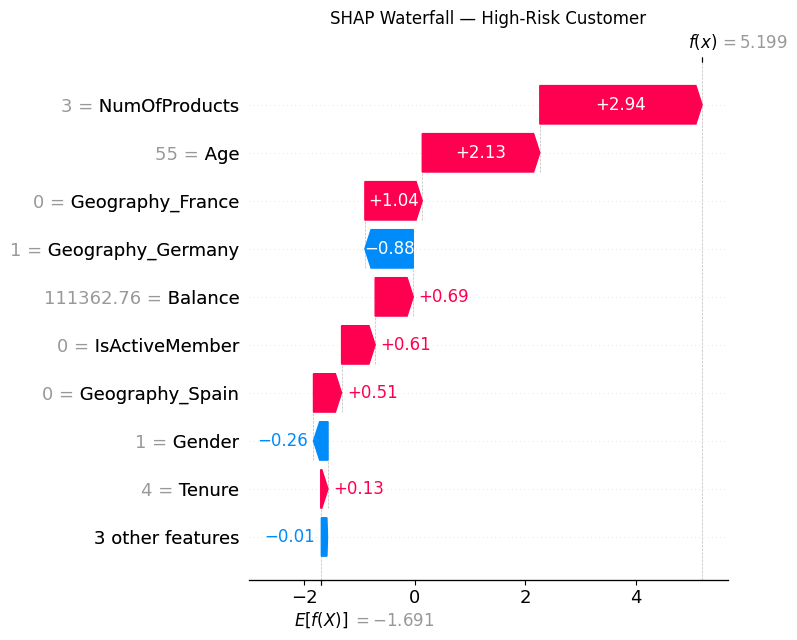

In [29]:
# SHAP Waterfall for a single high-risk customer
# Find the highest-probability churner in test set
high_risk_idx = np.argmax(trained_models['XGBoost'].predict_proba(X_test)[:, 1])
print(f'Explaining prediction for test customer #{high_risk_idx}')
print(f'Actual label   : {y_test.iloc[high_risk_idx]}')
print(f'Predicted prob : {trained_models["XGBoost"].predict_proba(X_test)[high_risk_idx, 1]:.4f}')

shap.waterfall_plot(shap_values[high_risk_idx], show=False)
plt.title('SHAP Waterfall — High-Risk Customer', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 9: Save the Best Models

In [30]:
import pickle
import joblib

# Save DNN in H5 format (Section 3.6)
dnn_model.save('churn_dnn_model.h5')
print('✅ DNN saved as churn_dnn_model.h5')

# Save XGBoost and scaler with pickle
with open('churn_xgboost_model.pkl', 'wb') as f:
    pickle.dump(trained_models['XGBoost'], f)
print('✅ XGBoost saved as churn_xgboost_model.pkl')

joblib.dump(scaler, 'scaler.pkl')
print('✅ Scaler saved as scaler.pkl')

✅ DNN saved as churn_dnn_model.h5
✅ XGBoost saved as churn_xgboost_model.pkl
✅ Scaler saved as scaler.pkl


In [31]:
# Download files to your local machine
from google.colab import files

files.download('churn_dnn_model.h5')
files.download('churn_xgboost_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔮 Step 10: Single Customer Prediction (Inference Example)

In [32]:
def predict_churn(customer_dict, model_type='dnn'):
    """
    Predict churn probability for a single customer.

    Parameters
    ----------
    customer_dict : dict  — raw customer features
    model_type    : 'dnn' | 'xgb'
    """
    # Build a single-row dataframe matching training schema
    sample = pd.DataFrame([customer_dict])

    # Encode Gender
    sample['Gender'] = le.transform(sample['Gender'])

    # One-hot Geography
    sample = pd.get_dummies(sample, columns=['Geography'], drop_first=False)

    # Align columns with training set
    for col in X.columns:
        if col not in sample.columns:
            sample[col] = 0
    sample = sample[X.columns]

    # Scale
    sample_sc = scaler.transform(sample)

    if model_type == 'dnn':
        prob = dnn_model.predict(sample_sc)[0][0]
    else:
        prob = trained_models['XGBoost'].predict_proba(sample)[0][1]

    risk = 'HIGH RISK 🔴' if prob >= 0.5 else ('MEDIUM RISK 🟡' if prob >= 0.3 else 'LOW RISK 🟢')
    print(f'Churn Probability : {prob:.4f}  ({prob*100:.1f}%)')
    print(f'Risk Level        : {risk}')
    return prob


# Example prediction
example_customer = {
    'CreditScore'    : 620,
    'Geography'      : 'Germany',
    'Gender'         : 'Female',
    'Age'            : 45,
    'Tenure'         : 3,
    'Balance'        : 130000.0,
    'NumOfProducts'  : 1,
    'HasCrCard'      : 1,
    'IsActiveMember' : 0,
    'EstimatedSalary': 82000.0,
}

print('=== DNN Prediction ===')
predict_churn(example_customer, model_type='dnn')

print('\n=== XGBoost Prediction ===')
predict_churn(example_customer, model_type='xgb')

=== DNN Prediction ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Churn Probability : 0.8976  (89.8%)
Risk Level        : HIGH RISK 🔴

=== XGBoost Prediction ===
Churn Probability : 0.9222  (92.2%)
Risk Level        : HIGH RISK 🔴


np.float32(0.92219007)

---
## ✅ Summary

| Objective | Status |
|-----------|--------|
| 1. EDA & feature analysis | ✅ Completed |
| 2. DNN model developed | ✅ Completed |
| 3. Evaluation with Accuracy, Precision, Recall, F1, AUC, Confusion Matrix | ✅ Completed |
| 4. SHAP explainability | ✅ Completed |

**Generated files:** `churn_dnn_model.h5`, `churn_xgboost_model.pkl`, `scaler.pkl`, and all plot `.png` files.

> *Finley Barongo Magembe — CT204/109437/22 — Meru University of Science and Technology*